<a href="https://colab.research.google.com/github/rstar900/PySDR/blob/main/02_IQ_Sampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The code in this notebook is based on https://pysdr.org/content/sampling.html

#My Take

IQ Sampling allows one to convert a signal to baseband (centered around 0) and do phase and amplitude measurements. This is possible due to some trignometric properties of the sine and cosine signals and an invention known as the mixer.

Meaning, instead of doing a direct sampling which relies on Nyquist frequency (2 times the source signal's frequency), one can do reception and transmission with a much cheaper oscillator which is close to the source signal's frequency.

Example: If the source signal has a frequency of 2.4 GHz, direct sampling would require sampling at 4.8 GHz. Now with IQ Sampling, we can use a local oscillator of say 2.4 GHz, then we get a signal centered around 0 Hz. For example, if original bandwidth was 40 Mhz, then we should get -/+ 20 MHz on left and right side of the 0 Hz.

It is like measuring the same signal from 2 different angles, just like looking at the world with 2 eyes instead of one, giving depth. But in this case, it allows to encode and decode information, i.e. the phase (specially) and amplitude, that would otherwise be ambiguous, if we just measure signal once. Also reducing the cost of oscillator as compared to the case of direct sampling.

I (In-Phase) is the signal with the original phase, and Q (Quadrature) is the signal shifted by 90 degrees. This is possible as we mix the source signal with local oscillator signal 2 times, once with in-phase and then with 90 degree shifted local oscillator, then we get 2 different signals (I and Q) (we also use a lowpass filter to remove the addition of both signals), with which we can determine amplitude and phase easily and also counter negative frequencies by looking which signal leads and which one lags.

# Additional resource to understand IQ sampling

I would recommend watching the video ```UKHAS 2015 IQ Sampling and Software Defined Radio - Adam Greig``` on youtube at https://www.youtube.com/watch?v=sWu97VqWRxU to understand with a practical example on GNU Radio


# My own example based on the above video
After watching the video above, I recommend doing a hands-on on GNU Radio Companion to see the waves in action. I have prepared one flowgraph (.grc), which you can play with as well or refer to in case there are some doubts.
The source files for which are available here

https://github.com/rstar900/GNU-Radio/tree/main/Miscellaneous/01_IQ_Sampling

# Calculating Spectral Power Density (PSD)

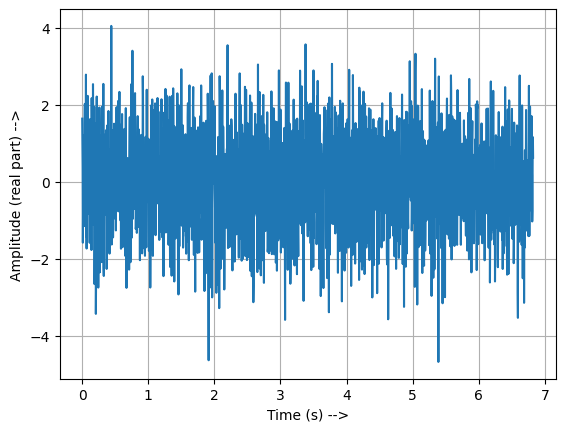

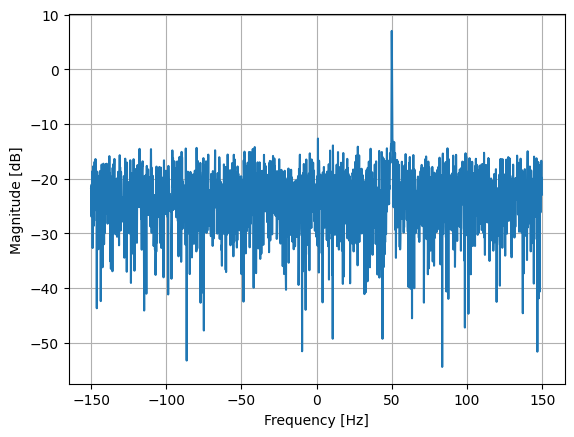

In [19]:
import numpy as np
import matplotlib.pyplot as plt

Fs = 300 # 300 Hz as sampling frequency
Ts = 1 / Fs # Sample period
N = 2048 # Number of samples

# Time domain function (x(t))
t = np.arange(N) * Ts
x = np.exp(1j*2*np.pi*50*t) # Sinusoid at 50 Hz

# Noise
n = (np.random.randn(N) + 1j*np.random.randn(N))/np.sqrt(2) # Complex noise with unity power
noise_power = 2
r = x + n * np.sqrt(noise_power) # Adding noise to x(t)

# Plot x(t) with added noise (r(t))
plt.figure(0)
#plt.plot(t[:100], r.real[:100]) # just plot 100 points
plt.plot(t, r.real)
plt.xlabel("Time (s) -->")
plt.ylabel("Amplitude (real part) -->")
plt.grid(True)
#plt.show() # can be commented now as we can call at the very end to plot all graphs

# Calculate PSD as a function in frequency domain (PSD_shifted(f))
PSD = np.abs(np.fft.fft(r))**2 / (N*Fs)
PSD_log = 10.0 * np.log10(PSD)
PSD_shifted = np.fft.fftshift(PSD_log)

# Frequency domain function
# Add frequency index from -Fs/2 to Fs/2 at intervals of Fs/N
f = np.arange(-Fs/2.0, Fs/2.0, Fs/N)

# Plot PSD_shifted(f)
plt.figure(1)
plt.plot(f, PSD_shifted)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [dB]")
plt.grid(True)
plt.show()

